# 05 — A hedge ratio that moves: the Kalman filter

The static hedge fits one $\beta$ for the whole sample. Real relationships drift, so here I let $\beta$
vary through time by modelling the pair as a linear-Gaussian state-space system and running a **Kalman
filter**. The useful by-product is the filter's one-step forecast error, which turns out to be a
look-ahead-free spread. (Full derivation in the note *Kalman Dynamic Hedge Ratio*.)

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from statarb import config, data, backtest, kalman, significance as sig
from statarb.signals import hedge_ratio

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
BLUE, ORANGE, GREEN, GREY = "#0072B2", "#E69F00", "#009E73", "#8A8F98"
semis = data.align_prices(pd.read_csv("../data/semis.csv", index_col=0, parse_dates=True))
allp = data.align_prices(pd.read_csv("../data/pairs.csv", index_col=0, parse_dates=True))
pairs = allp[[t for t in config.PAIRS_UNIVERSE if t in allp.columns]]

## The model

Treat the regression coefficients as hidden states that drift as a random walk:
$$y_t = \alpha_t + \beta_t x_t + v_t,\qquad [\beta_t,\alpha_t] = [\beta_{t-1},\alpha_{t-1}] + w_t.$$
The filter carries an estimate of $[\beta,\alpha]$ and updates it each day: predict, compare the new price
to the prediction, and nudge the state by that surprise. The surprise itself,
$e_t = y_t - (\alpha_{t-1}+\beta_{t-1}x_t)$, uses only yesterday's state, so it carries no look-ahead — it
is the dynamic-hedge analogue of the static spread. The dial $\delta$ sets how fast $\beta$ is allowed to
move.

## When it helps: a drifting hedge

AMAT and LRCX are both wafer-fab equipment makers, and their relative pricing re-rates over the decade.
The filter tracks that: $\beta_t$ wanders while the single static OLS $\beta$ can only sit at the average.

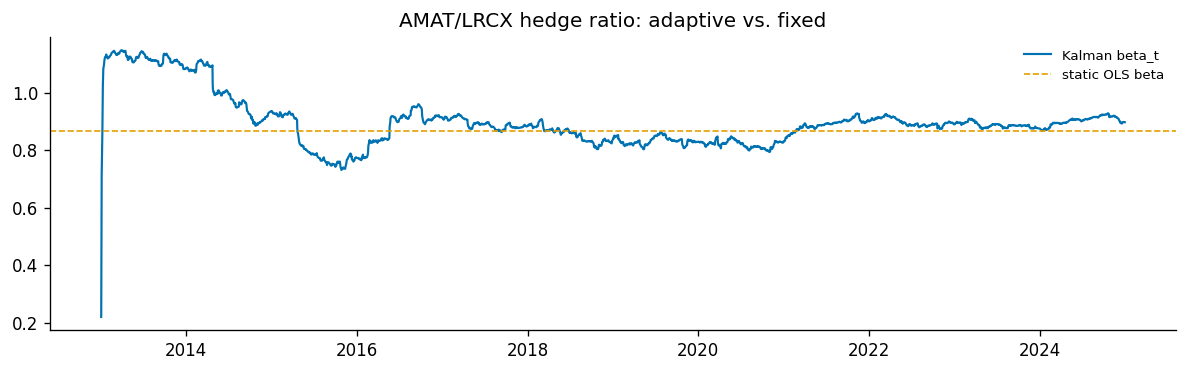

Kalman beta ranges 0.73–1.15; static OLS = 0.87


In [2]:
y, x = np.log(semis["AMAT"]), np.log(semis["LRCX"])
f = kalman.kalman_filter_hedge(y, x, delta=1e-4, obs_var=1e-3)
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(f["beta"].index, f["beta"], color=BLUE, lw=1.3, label="Kalman beta_t")
ax.axhline(hedge_ratio(y, x), ls="--", color=ORANGE, lw=1, label="static OLS beta")
ax.legend(frameon=False, fontsize=8); ax.set_title("AMAT/LRCX hedge ratio: adaptive vs. fixed")
plt.tight_layout(); plt.show()
print(f"Kalman beta ranges {f['beta'].iloc[60:].min():.2f}–{f['beta'].iloc[60:].max():.2f}; static OLS = {hedge_ratio(y,x):.2f}")

## When it does not: a stable pair

Adaptivity is not free. If the hedge is already stable, letting $\beta$ move just chases noise and, worse,
absorbs the slow swing the static spread was trading. MA/V is the case in point: its $\beta$ barely
moves, so the Kalman version trades rarely and underperforms the static walk-forward. A dynamic hedge is
the right tool for a drifting relationship, not a universal upgrade.

In [3]:
my, mx = np.log(pairs["MA"]), np.log(pairs["V"])
fk = kalman.kalman_filter_hedge(my, mx, delta=1e-4, obs_var=1e-3)
static = backtest.walk_forward(my, mx, train=252, step=63, entry=1.5, exit=0.0, cost=0.0005)
kal = kalman.kalman_backtest(my, mx, delta=1e-4, obs_var=1e-3, entry=1.0, exit=0.0, cost=0.0005, warmup=60)
print(f"MA/V Kalman beta drift: {fk['beta'].iloc[60]:.3f} -> {fk['beta'].iloc[-1]:.3f}  (std {fk['beta'].iloc[60:].std():.3f}, ~flat)")
print(f"static walk-forward Sharpe : {static['stats']['sharpe']:.2f}   trades {int((static['positions'].diff().abs()>0).sum())}")
print(f"Kalman Sharpe              : {kal['stats']['sharpe']:.2f}   trades {int((kal['positions'].diff().abs()>0).sum())}")

MA/V Kalman beta drift: 0.995 -> 1.018  (std 0.024, ~flat)
static walk-forward Sharpe : 1.26   trades 101
Kalman Sharpe              : -0.10   trades 2


So the Kalman filter earns its keep exactly when a pair's hedge ratio moves — and quietly hurts when
it does not. That judgement, knowing which regime a pair is in, matters more than the machinery itself.